# 1. Imports

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sys.path.append('../utils')
from myutils import display_report, plot_categorical_dual, plot_numeric_report

print("Libraries loaded.")

Библиотеки загружены.


# 2. Loading data

In [32]:
RAW_PATH   = "../data/raw/Spend (Done).xlsx"
CLEAN_PATH = "../data/clean/spend_clean.pkl"

df = pd.read_excel(RAW_PATH)
print(f"Size: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head(3)

Размер: (20779, 8)
Столбцы: ['Date', 'Source', 'Campaign', 'Impressions', 'Spend', 'Clicks', 'AdGroup', 'Ad']


,Date,Source,Campaign,Impressions,Spend,Clicks,AdGroup,Ad
0,2023-07-03,Google Ads,gen_analyst_DE,6,0.00,0,NaN,NaN
1,2023-07-03,Google Ads,performancemax_eng_DE,4,0.01,1,NaN,NaN
2,2023-07-03,Facebook Ads,NaN,0,0.00,0,NaN,NaN


# 3. Overview

In [33]:
display_report(df, df_name="Spend (raw)")

  ОТЧЁТ: Spend (raw)
  Размер : 20,779 строк × 8 столбцов
  Память : 2.01 MB

  Пропуски (NaN):
    Campaign                                   5994 (28.8%)
    AdGroup                                    6828 (32.9%)
    Ad                                         6828 (32.9%)

  КАТЕГОРИАЛЬНЫЕ столбцы:
  column dtype  n_unique         top_value  top_freq  top_pct  null_count  null_pct
  Source   str        14      Facebook Ads      9732    46.84           0      0.00
Campaign   str        51 12.07.2023wide_DE      2073     9.98        5994     28.85
 AdGroup   str        24              wide      5451    26.23        6828     32.86
      Ad   str       176 bloggersvideo9com       714     3.44        6828     32.86

  ЧИСЛОВЫЕ столбцы:
     column  count    mean  median  mode      std  min      max    range  null_count  null_pct
Impressions  20779 2458.20   63.00   0.0 11442.53  0.0 431445.0 431445.0           0       0.0
      Spend  20779    7.20    0.58   0.0    26.76  0.0    774.0   

# 4. Dates

In [34]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["year_month"] = df["Date"].dt.to_period("M")

print(f"Date range: {df['Date'].min()} — {df['Date'].max()}")

Диапазон дат: 2023-07-03 00:00:00 — 2024-06-21 00:00:00


In [35]:
df["year_month"]

0        2023-07
1        2023-07
2        2023-07
3        2023-07
4        2023-07
          ...   
20774    2024-06
20775    2024-06
20776    2024-06
20777    2024-06
20778    2024-06
Name: year_month, Length: 20779, dtype: period[M]

In [36]:
df["Date"]

0       2023-07-03
1       2023-07-03
2       2023-07-03
3       2023-07-03
4       2023-07-03
           ...    
20774   2024-06-21
20775   2024-06-21
20776   2024-06-21
20777   2024-06-21
20778   2024-06-21
Name: Date, Length: 20779, dtype: datetime64[us]

# 5. Numeric fields validation

In [73]:
# Impressions, clicks, and spend cannot be negative
for col in ["Impressions", "Clicks", "Spend"]:
    neg = (df[col] < 0).sum()
    if neg > 0:
        print(f"WARNING: {neg} negative values in '{col}' -> replacing with 0")
        df.loc[df[col] < 0, col] = 0

In [38]:
# Logical validation: clicks cannot exceed impressions
invalid = (df["Clicks"] > df["Impressions"]).sum()
print(f"Rows where clicks > impressions: {invalid}")

if invalid > 0:
    # Limit clicks to the number of impressions
    df.loc[df["Clicks"] > df["Impressions"], "Clicks"] = \
        df.loc[df["Clicks"] > df["Impressions"], "Impressions"]

print("\nStatistics after validation:")
df[["Impressions", "Clicks", "Spend"]].describe()

Строк, где clicks > Impressions: 1370

Статистика после валидации:


,Impressions,Clicks,Spend
count,20779.000000,20779.000000,20779.000000
mean,2458.203475,20.186149,7.195892
std,11442.528075,82.619411,26.760080
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,63.000000,1.000000,0.580000
75%,709.000000,9.000000,5.750000
max,431445.000000,2415.000000,774.000000


# 6. Missing values

In [39]:
print("Missing values before cleaning:")
print(df.isna().sum()[df.isna().sum() > 0])

Пропуски до:
Campaign    5994
AdGroup     6828
Ad          6828
dtype: int64


In [40]:
# Campaign, ad group, and ad can be empty for organic traffic
df["Campaign"] = df["Campaign"].fillna("Not set")
df["AdGroup"] = df["AdGroup"].fillna("Not set")
df["Ad"] = df["Ad"].fillna("Not set")
df["Source"] = df["Source"].fillna("Not set")

print("\nMissing values after cleaning:")
r = df.isna().sum()
print(r[r > 0] if r.any() else "No missing values.")


Пропуски после:
Пропусков нет.


In [41]:
df

,Date,Source,Campaign,Impressions,Spend,Clicks,AdGroup,Ad,year_month
0,2023-07-03,Google Ads,gen_analyst_DE,6,0.00,0,Not set,Not set,2023-07
1,2023-07-03,Google Ads,performancemax_eng_DE,4,0.01,1,Not set,Not set,2023-07
2,2023-07-03,Facebook Ads,Not set,0,0.00,0,Not set,Not set,2023-07
3,2023-07-03,Google Ads,Not set,0,0.00,0,Not set,Not set,2023-07
4,2023-07-03,CRM,Not set,0,0.00,0,Not set,Not set,2023-07
...,...,...,...,...,...,...,...,...,...
20774,2024-06-21,Facebook Ads,17.03.24wide_AT,7,0.07,0,wide,bloggersvideo16com_at,2024-06
20775,2024-06-21,Tiktok Ads,12.07.2023wide_DE,61,0.16,0,wide,bloggersvideo14com,2024-06
20776,2024-06-21,Partnership,Not set,0,0.00,0,Not set,Not set,2024-06
20777,2024-06-21,Tiktok Ads,Not set,0,0.00,0,Not set,Not set,2024-06


# 7. Duplicates

In [42]:
dups = df.duplicated().sum()
print(f"Full duplicate rows: {dups}")

Полных дубликатов строк: 1206


In [43]:
# Display only duplicate rows (excluding the first occurrence)
duplicates = df[df.duplicated()]
duplicates

,Date,Source,Campaign,Impressions,Spend,Clicks,AdGroup,Ad,year_month
755,2023-07-23,Bloggers,Not set,0,0.0,0,Not set,Not set,2023-07
789,2023-07-24,Bloggers,Not set,0,0.0,0,Not set,Not set,2023-07
844,2023-07-25,Bloggers,Not set,0,0.0,0,Not set,Not set,2023-07
899,2023-07-26,Bloggers,Not set,0,0.0,0,Not set,Not set,2023-07
958,2023-07-27,Bloggers,Not set,0,0.0,0,Not set,Not set,2023-07
...,...,...,...,...,...,...,...,...,...
20745,2024-06-21,Bloggers,Not set,0,0.0,0,Not set,Not set,2024-06
20746,2024-06-21,Facebook Ads,Not set,0,0.0,0,Not set,Not set,2024-06
20750,2024-06-21,SMM,Not set,0,0.0,0,Not set,Not set,2024-06
20764,2024-06-21,Telegram posts,Not set,0,0.0,0,Not set,Not set,2024-06


In [44]:
duplicates_all.sort_values(by=list(df.columns))

,Date,Source,Campaign,Impressions,Spend,Clicks,AdGroup,Ad,year_month
753,2023-07-23,Bloggers,Not set,0,0.0,0,Not set,Not set,2023-07
755,2023-07-23,Bloggers,Not set,0,0.0,0,Not set,Not set,2023-07
768,2023-07-24,Bloggers,Not set,0,0.0,0,Not set,Not set,2023-07
789,2023-07-24,Bloggers,Not set,0,0.0,0,Not set,Not set,2023-07
841,2023-07-25,Bloggers,Not set,0,0.0,0,Not set,Not set,2023-07
...,...,...,...,...,...,...,...,...,...
20773,2024-06-21,Organic,Not set,0,0.0,0,Not set,Not set,2024-06
20738,2024-06-21,SMM,Not set,0,0.0,0,Not set,Not set,2024-06
20750,2024-06-21,SMM,Not set,0,0.0,0,Not set,Not set,2024-06
20729,2024-06-21,Telegram posts,Not set,0,0.0,0,Not set,Not set,2024-06


In [45]:
# Check duplicates before removal
duplicates_all = df[df.duplicated(keep=False)]

print(f"Total rows in duplicate groups: {len(duplicates_all)}")
display(duplicates_all.head(20))

Всего строк в дублирующихся группах: 1968


,Date,Source,Campaign,Impressions,Spend,Clicks,AdGroup,Ad,year_month
753,2023-07-23,Bloggers,Not set,0,0.0,0,Not set,Not set,2023-07
755,2023-07-23,Bloggers,Not set,0,0.0,0,Not set,Not set,2023-07
768,2023-07-24,Bloggers,Not set,0,0.0,0,Not set,Not set,2023-07
789,2023-07-24,Bloggers,Not set,0,0.0,0,Not set,Not set,2023-07
841,2023-07-25,Bloggers,Not set,0,0.0,0,Not set,Not set,2023-07
844,2023-07-25,Bloggers,Not set,0,0.0,0,Not set,Not set,2023-07
895,2023-07-26,Bloggers,Not set,0,0.0,0,Not set,Not set,2023-07
899,2023-07-26,Bloggers,Not set,0,0.0,0,Not set,Not set,2023-07
950,2023-07-27,Bloggers,Not set,0,0.0,0,Not set,Not set,2023-07
958,2023-07-27,Bloggers,Not set,0,0.0,0,Not set,Not set,2023-07


In [48]:
df = df.drop_duplicates().reset_index(drop=True)

print(f"Full duplicate rows were removed because they did not contain new information and were caused by repeated data exports.")
print(f"Keeping them would distort aggregated metrics (Spend, Clicks, Impressions).")
print()
print(f"Size after removal: {df.shape}")

Удалены полные дубликаты строк, так как они не содержат новой информации и являются результатом повторной выгрузки данных.
Сохранение их искажало бы агрегированные метрики (Spend, Clicks, Impressions).

Размер после: (19573, 9)


In [50]:
duplicates2 = df[df.duplicated()]
duplicates2

,Date,Source,Campaign,Impressions,Spend,Clicks,AdGroup,Ad,year_month


# 8. Data types

In [51]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19573 entries, 0 to 19572
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         19573 non-null  datetime64[us]
 1   Source       19573 non-null  str           
 2   Campaign     19573 non-null  str           
 3   Impressions  19573 non-null  int64         
 4   Spend        19573 non-null  float64       
 5   Clicks       19573 non-null  int64         
 6   AdGroup      19573 non-null  str           
 7   Ad           19573 non-null  str           
 8   year_month   19573 non-null  period[M]     
dtypes: datetime64[us](1), float64(1), int64(2), period[M](1), str(4)
memory usage: 2.2 MB


In [52]:
df["Source"] = df["Source"].astype("category")
df["Campaign"] = df["Campaign"].astype("category")
df["AdGroup"] = df["AdGroup"].astype("category")
df["Ad"] = df["Ad"].astype("category")

df.dtypes

Date           datetime64[us]
Source               category
Campaign             category
Impressions             int64
Spend                 float64
Clicks                  int64
AdGroup              category
Ad                   category
year_month          period[M]
dtype: object

# 9. Feature Engineering: advertising metrics

In [53]:
# CTR = Click-Through Rate
df["ctr"] = np.where(df["Impressions"] > 0, (df["Clicks"] / df["Impressions"] * 100).round(4), 0.0)

In [56]:
# CPC = Cost Per Click
df["cpc"] = np.where(df["Clicks"] > 0, (df["Spend"] / df["Clicks"]).round(4), 0.0)

In [58]:
# CPM = Cost Per 1000 Impressions
df["cpm"] = np.where(df["Impressions"] > 0, (df["Spend"] / df["Impressions"] * 1000).round(4), 0.0)

In [63]:
print("CTR, CPC, and CPM metrics calculated:")
print(df[["ctr", "cpc", "cpm"]].describe())

Метрики CTR, CPC, CPM рассчитаны:
                ctr           cpc           cpm
count  19573.000000  19573.000000  19573.000000
mean       1.335926      0.410974     11.855957
std        4.207862      0.757865     50.577600
min        0.000000      0.000000      0.000000
25%        0.000000      0.000000      0.000000
50%        0.378800      0.130900      5.093000
75%        1.380700      0.582500     12.439300
max      100.000000     26.666700   1558.871000


In [64]:
df

,Date,Source,Campaign,Impressions,Spend,Clicks,AdGroup,Ad,year_month,ctr,cpc,cpm
0,2023-07-03,Google Ads,gen_analyst_DE,6,0.00,0,Not set,Not set,2023-07,0.0000,0.00,0.0000
1,2023-07-03,Google Ads,performancemax_eng_DE,4,0.01,1,Not set,Not set,2023-07,25.0000,0.01,2.5000
2,2023-07-03,Facebook Ads,Not set,0,0.00,0,Not set,Not set,2023-07,0.0000,0.00,0.0000
3,2023-07-03,Google Ads,Not set,0,0.00,0,Not set,Not set,2023-07,0.0000,0.00,0.0000
4,2023-07-03,CRM,Not set,0,0.00,0,Not set,Not set,2023-07,0.0000,0.00,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...
19568,2024-06-21,Facebook Ads,17.03.24wide_AT,7,0.07,0,wide,bloggersvideo16com_at,2024-06,0.0000,0.00,10.0000
19569,2024-06-21,Tiktok Ads,12.07.2023wide_DE,61,0.16,0,wide,bloggersvideo14com,2024-06,0.0000,0.00,2.6230
19570,2024-06-21,Partnership,Not set,0,0.00,0,Not set,Not set,2024-06,0.0000,0.00,0.0000
19571,2024-06-21,Tiktok Ads,Not set,0,0.00,0,Not set,Not set,2024-06,0.0000,0.00,0.0000


# 10. Final report

In [65]:
display_report(df, df_name="Spend (clean)")

  ОТЧЁТ: Spend (clean)
  Размер : 19,573 строк × 12 столбцов
  Память : 1.29 MB

  Пропусков нет.

  КАТЕГОРИАЛЬНЫЕ столбцы:
  column    dtype  n_unique    top_value  top_freq  top_pct  null_count  null_pct
  Source category        14 Facebook Ads      9569    48.89           0       0.0
Campaign category        52      Not set      4788    24.46           0       0.0
 AdGroup category        25      Not set      5622    28.72           0       0.0
      Ad category       177      Not set      5622    28.72           0       0.0

  ЧИСЛОВЫЕ столбцы:
     column  count    mean  median  mode      std  min         max       range  null_count  null_pct
Impressions  19573 2609.67   90.00   0.0 11773.02  0.0 431445.0000 431445.0000           0       0.0
      Spend  19573    7.64    0.80   0.0    27.51  0.0    774.0000    774.0000           0       0.0
     Clicks  19573   21.43    1.00   0.0    84.97  0.0   2415.0000   2415.0000           0       0.0
        ctr  19573    1.34    0.38   0.0

# 11. Visualizations

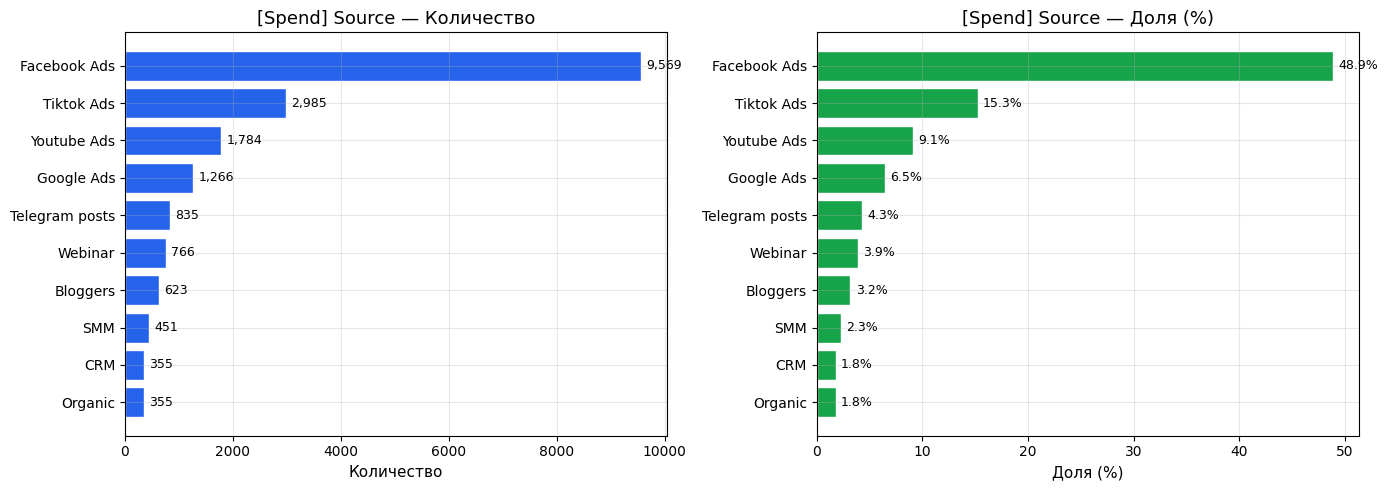

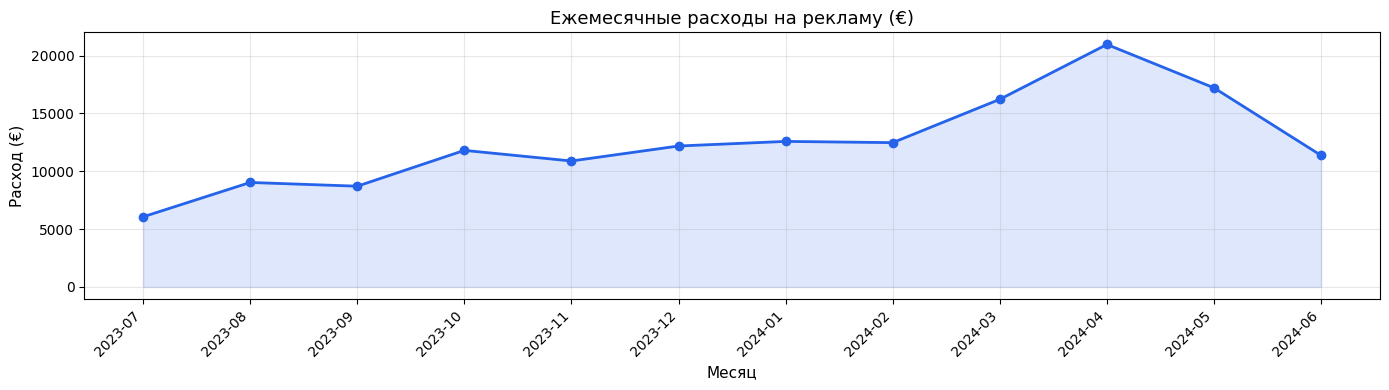

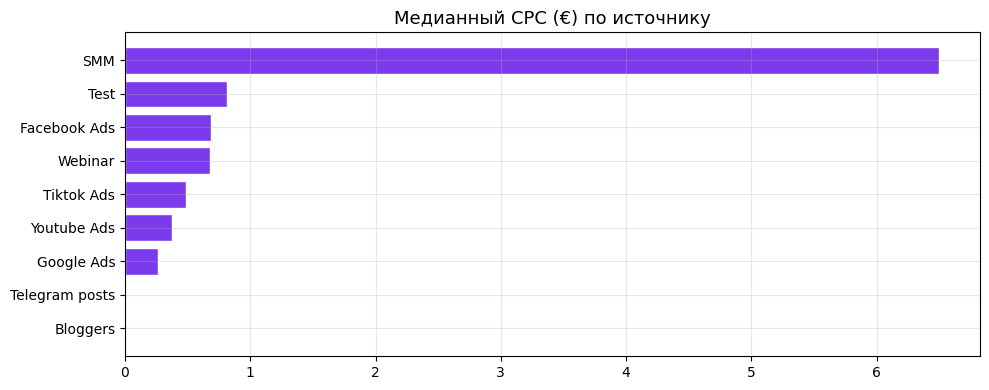

In [67]:
# 1. Traffic sources
plot_categorical_dual(df["Source"], col_name="Source",
                      df_name="Spend", top_n=10)

# 2. Monthly advertising spend dynamics
monthly_spend = (
    df.groupby("year_month")["Spend"]
    .sum()
    .reset_index()
)
monthly_spend["month"] = monthly_spend["year_month"].astype(str)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(monthly_spend["month"], monthly_spend["Spend"],
        marker="o", color="#2563EB", linewidth=2)
ax.fill_between(range(len(monthly_spend)), monthly_spend["Spend"],
                alpha=0.15, color="#2563EB")
ax.set_title("Monthly advertising spend (€)", fontsize=13)
ax.set_xlabel("Month")
ax.set_ylabel("Spend (€)")
ax.set_xticks(range(len(monthly_spend)))
ax.set_xticklabels(monthly_spend["month"], rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 3. CPC by source
cpc_src = (
    df[df["Clicks"] > 0]
    .groupby("Source")["cpc"]
    .median()
    .sort_values(ascending=True)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(cpc_src["Source"], cpc_src["cpc"],
        color="#7C3AED", edgecolor="white")
ax.set_title("Median CPC (€) by source", fontsize=13)
plt.tight_layout()
plt.show()

# 12. Key insights

In [71]:
total_spend  = df["Spend"].sum()
total_clicks = df["Clicks"].sum()
total_impr   = df["Impressions"].sum()
ctr_overall  = total_clicks / total_impr * 100
cpc_overall  = total_spend / total_clicks if total_clicks > 0 else 0

print(f"Total spend        : €{total_spend:,.2f}")
print(f"Total clicks       : {total_clicks:,}")
print(f"Total impressions  : {total_impr:,}")
print(f"Overall CTR        : {ctr_overall:.2f}%")
print(f"Overall CPC        : €{cpc_overall:.2f}")

print("\nTop-10 campaigns by spend:")
print(df.groupby("Campaign")["Spend"].sum()
        .sort_values(ascending=False).head(10))

Общие расходы      : €149,523.45
Всего кликов       : 419,448
Всего показов      : 51,079,010
Общий CTR          : 0.82%
Общий CPC          : €0.36

Топ-10 кампаний по расходам:
Campaign
performancemax_eng_DE        34183.45
Not set                      27887.68
youtube_shorts_DE            14149.22
discovery_DE                  9750.63
12.07.2023wide_DE             9471.52
02.07.23wide_DE               6913.60
04.07.23recentlymoved_DE      4523.31
03.07.23women                 4219.75
07.07.23LAL_DE                4200.37
12.09.23interests_Uxui_DE     3753.06
Name: Spend, dtype: float64


# 13. Saving

In [72]:
df.to_pickle(CLEAN_PATH)
print(f"Saved: {CLEAN_PATH}")
print(f"Size: {df.shape}")

Сохранено: ../data/clean/spend_clean.pkl
Размер: (19573, 12)
